# 07. Final Evaluation

This notebook brings together the tabular models (Notebook 04) and the CNN (Notebook 06)
and performs the single evaluation on the test period.

1. **Reproduce** the predictions of the best tabular model, XGB Weather + Context, on 2023.
2. **Combination test**: does the image network add information beyond the best tabular
   model? The two models' probabilities are averaged with **fixed equal weights (50/50)**.
   The weights were set **before** looking at the results, so that 2023 is not used to
   tune the combination.
3. **Final model decisions**, taken before the test data are used.
4. **Single evaluation on the test period (2024–2025).**

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.metrics import average_precision_score, roc_auc_score, brier_score_loss
from xgboost import XGBClassifier

PROCESSED_DIR = Path("../data/processed")
CNN_DIR = PROCESSED_DIR / "cnn_outputs"
TARGET = "fire_next_7_days"

WEATHER_FEATURES = [
    "consecutive_dry_days", "potential_evaporation_sum_7d",
    "precipitation_sum_14d", "precipitation_sum_30d", "precipitation_sum_7d",
    "relative_humidity_mean_7d", "soil_moisture_change_7d",
    "soil_moisture_last_day", "soil_moisture_mean_7d", "solar_radiation_sum_7d",
    "temperature_max_7d", "temperature_mean_7d", "vpd_mean_7d",
    "water_balance_7d", "wind_speed_max_daily_mean_7d", "wind_speed_mean_7d",
]
CONTEXT_FEATURES = [
    "climatology_rate", "fires_prev_1w", "fires_prev_4w",
    "vegetation_fraction", "land_fraction",
]
XGB_FEATURES = WEATHER_FEATURES + CONTEXT_FEATURES

df = pd.read_parquet(PROCESSED_DIR / "model_dataset_full.parquet")
print(df.shape)

(875238, 44)


In [15]:
xgb_configs = [
    {
        "max_depth": 3,
        "learning_rate": 0.05,
        "min_child_weight": 5,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
    },
    {
        "max_depth": 5,
        "learning_rate": 0.05,
        "min_child_weight": 5,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
    },
    {
        "max_depth": 7,
        "learning_rate": 0.05,
        "min_child_weight": 5,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
    },
    {
        "max_depth": 5,
        "learning_rate": 0.10,
        "min_child_weight": 5,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
    },
    {
        "max_depth": 5,
        "learning_rate": 0.05,
        "min_child_weight": 1,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
    },
    {
        "max_depth": 5,
        "learning_rate": 0.05,
        "min_child_weight": 10,
        "subsample": 1.0,
        "colsample_bytree": 1.0,
    },
]

In [16]:
def add_climatology_feature(train_part, apply_parts):
    """
    Adds 'climatology_rate' (historical fire rate per cell × month).

    - train_part rows: leave-one-year-out rate (own year excluded) to avoid
      target leakage.
    - apply_parts rows (validation folds): rate from all train_part years.
    """
    train_part = train_part.copy()
    train_part["month"] = train_part["reference_date"].dt.month

    total = (
        train_part
        .groupby(["cell_id", "month"])["fire_next_7_days"]
        .agg(total_sum="sum", total_count="size")
        .reset_index()
    )

    by_year = (
        train_part
        .groupby(["cell_id", "month", "iso_year"])["fire_next_7_days"]
        .agg(year_sum="sum", year_count="size")
        .reset_index()
    )

    loyo = by_year.merge(total, on=["cell_id", "month"])
    loyo["climatology_rate"] = (
        (loyo["total_sum"] - loyo["year_sum"])
        / (loyo["total_count"] - loyo["year_count"])
    )

    train_part = train_part.merge(
        loyo[["cell_id", "month", "iso_year", "climatology_rate"]],
        on=["cell_id", "month", "iso_year"],
        how="left",
        validate="many_to_one",
    )

    total["climatology_rate"] = total["total_sum"] / total["total_count"]

    applied = []
    for part in apply_parts:
        part = part.copy()
        part["month"] = part["reference_date"].dt.month
        part = part.merge(
            total[["cell_id", "month", "climatology_rate"]],
            on=["cell_id", "month"],
            how="left",
            validate="many_to_one",
        )
        applied.append(part)

    return train_part, applied

In [17]:
XGB_CONFIG_ID = 5
XGB_TREES = 88

train_df = df[df["iso_year"].between(2017, 2022)]
val_df = df[df["iso_year"] == 2023]

train_final, (val_final,) = add_climatology_feature(train_df, [val_df])

xgb_model = XGBClassifier(
    objective="binary:logistic",
    n_estimators=XGB_TREES,
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
    **xgb_configs[XGB_CONFIG_ID - 1],
)
xgb_model.fit(train_final[XGB_FEATURES], train_final[TARGET])

val_final["xgb_prob"] = xgb_model.predict_proba(val_final[XGB_FEATURES])[:, 1]

xgb_ap = average_precision_score(val_final[TARGET], val_final["xgb_prob"])
print(f"XGB Weather + Context, AP 2023: {xgb_ap:.4f} (Notebook 04: 0.2385)")
assert abs(xgb_ap - 0.2385) < 0.001

XGB Weather + Context, AP 2023: 0.2385 (Notebook 04: 0.2385)


In [18]:
cnn = pd.read_parquet(CNN_DIR / "cnn_predictions_2023.parquet")
cnn["reference_date"] = pd.to_datetime(cnn["reference_date"])

merged = val_final[["cell_id", "reference_date", TARGET, "xgb_prob"]].merge(
    cnn, on=["cell_id", "reference_date"], how="inner", validate="one_to_one",
)

assert len(merged) == 99_372
assert (merged[TARGET].values == merged["y"].values).all()

for col in ["xgb_prob", "tabular_mean", "image_mean"]:
    print(f"{col:13s} AP = {average_precision_score(merged['y'], merged[col]):.4f}")

xgb_prob      AP = 0.2385
tabular_mean  AP = 0.2339
image_mean    AP = 0.2398


## Combination test

If the image network carries information that the tabular model does not have, averaging
the two models' probabilities should improve on the tabular model alone. If it only
reproduces what the tabular model already knows, the average should be no better.

The combination uses **fixed equal weights**:

$$p_{\text{combined}} = 0.5 \cdot p_{\text{XGB}} + 0.5 \cdot p_{\text{CNN image}}$$

Both models were trained on the same years, with the same prevalence and without
subsampling, so their probabilities are on comparable scales.

In [19]:
def paired_bootstrap_ap(y_true, score_a, score_b, weeks, n_boot=1000, seed=42):
    """AP(score_b) - AP(score_a), resampling whole weeks with replacement."""
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    score_a = np.asarray(score_a)
    score_b = np.asarray(score_b)
    weeks = np.asarray(weeks)

    unique_weeks = np.unique(weeks)
    week_rows = {w: np.flatnonzero(weeks == w) for w in unique_weeks}

    diffs = []
    for _ in range(n_boot):
        sampled = rng.choice(unique_weeks, size=len(unique_weeks), replace=True)
        idx = np.concatenate([week_rows[w] for w in sampled])
        diffs.append(
            average_precision_score(y_true[idx], score_b[idx])
            - average_precision_score(y_true[idx], score_a[idx])
        )

    diffs = np.array(diffs)
    return {
        "mean_diff": diffs.mean(),
        "ci_low": np.percentile(diffs, 2.5),
        "ci_high": np.percentile(diffs, 97.5),
        "share_positive": (diffs > 0).mean(),
    }

In [20]:
merged["combined"] = 0.5 * merged["xgb_prob"] + 0.5 * merged["image_mean"]

print(f"Combined AP = {average_precision_score(merged['y'], merged['combined']):.4f}")

comparisons = {
    "XGB → CNN image": ("xgb_prob", "image_mean"),
    "XGB → XGB + CNN image (50/50)": ("xgb_prob", "combined"),
}

combination_bootstrap = pd.DataFrame([
    {"comparison": name,
     **paired_bootstrap_ap(merged["y"], merged[a], merged[b], merged["reference_date"])}
    for name, (a, b) in comparisons.items()
])
combination_bootstrap

Combined AP = 0.2423


,comparison,mean_diff,ci_low,ci_high,share_positive
0,XGB → CNN image,0.001275,-0.004206,0.006825,0.678
1,XGB → XGB + CNN image (50/50),0.003744,0.001236,0.006238,0.997


In [21]:
merged["combined_tabular"] = 0.5 * merged["xgb_prob"] + 0.5 * merged["tabular_mean"]

for col in ["xgb_prob", "combined_tabular", "combined"]:
    print(f"{col:17s} AP = {average_precision_score(merged['y'], merged[col]):.4f}")

control_comparisons = {
    "XGB → XGB + CNN tabular (50/50)": ("xgb_prob", "combined_tabular"),
    "XGB + CNN tabular → XGB + CNN image": ("combined_tabular", "combined"),
}

control_bootstrap = pd.DataFrame([
    {"comparison": name,
     **paired_bootstrap_ap(merged["y"], merged[a], merged[b], merged["reference_date"])}
    for name, (a, b) in control_comparisons.items()
])
control_bootstrap

xgb_prob          AP = 0.2385
combined_tabular  AP = 0.2381
combined          AP = 0.2423


,comparison,mean_diff,ci_low,ci_high,share_positive
0,XGB → XGB + CNN tabular (50/50),-0.000344,-0.002316,0.001543,0.358
1,XGB + CNN tabular → XGB + CNN image,0.004088,0.002631,0.005664,1.000


### Results

| Model | AP 2023 |
|---|---:|
| XGB Weather + Context | 0.2385 |
| CNN tabular only (3-seed ensemble) | 0.2339 |
| CNN image + tabular (3-seed ensemble) | 0.2398 |
| XGB + CNN tabular (50/50) | 0.2381 |
| **XGB + CNN image (50/50)** | **0.2423** |

Paired block bootstrap over weeks (1,000 resamples):

| Comparison | Mean ΔAP | 95% CI | Share > 0 |
|---|---:|---|---:|
| XGB → CNN image | +0.0013 | [−0.0042, +0.0068] | 68% |
| XGB → XGB + CNN image | +0.0037 | [+0.0012, +0.0062] | 99.7% |
| XGB → XGB + CNN tabular | −0.0003 | [−0.0023, +0.0015] | 36% |
| **XGB + CNN tabular → XGB + CNN image** | **+0.0041** | **[+0.0026, +0.0057]** | **100%** |

**Control for the ensemble effect.** Averaging two different models often improves
performance even when the second model carries no new information, because their errors
partly cancel. To isolate the contribution of the image, the same 50/50 combination was
built with the tabular-only network. That combination brings **no improvement** over XGB
alone, whereas the combination with the image network does. The difference between the
two combinations (+0.0041, 95% CI excluding zero) is therefore attributable to the
**image**, not to model diversity.

**Conclusion.** The previous month's Sentinel-2 composite, read by a CNN, adds a **small
but robust** signal (≈ +1.7% in AP) beyond the best tabular model, which already knows
the weather, the historical fire climatology and recent fire persistence. Tabular
summaries of the same imagery (NDVI/NDMI statistics, Notebook 04) did not achieve this.

## Final decisions (fixed before using the test period)

1. **Primary model: XGB Weather + Context + CNN image (50/50 average of probabilities).**
   It achieved the best validation AP, and the image contribution was shown to be robust
   against an ensemble-effect control. XGB Weather + Context alone is also reported as the
   **operational alternative**: almost as accurate and far cheaper to run (no monthly
   composites, no GPU).
2. **No retraining on 2017–2023.** The models evaluated on the test period are exactly
   those validated on 2023 (trained on 2017–2022).
3. **Calibration: Platt scaling fitted on out-of-sample predictions for 2020–2023.**
   2020–2022 are predicted by fold models trained only on earlier years (XGB and the image
   network, same settings as the final models); 2023 is predicted by the final models.
   Calibrating on four years avoids tying the probabilities to 2023, the calmest year of
   the series.
4. **Test metrics:** Average Precision (primary), ROC-AUC and Brier score (calibrated
   primary model), for 2024–2025 pooled and for each year separately; precision@5% and
   recall@5% per week; paired block bootstrap for the main comparisons; and a descriptive
   analysis of fires ≥ 10 ha.

All other models (baselines and the tabular ablation ladder) are reported on the test
period for completeness, but the conclusions rest on the primary model.

## Calibration of the primary model

Out-of-sample predictions of both components are assembled for 2020–2023:

| Year | XGB Weather + Context | CNN image |
|---|---|---|
| 2020–2022 | fold models (expanding window, same settings) | fold networks (3 seeds) |
| 2023 | final model | final networks (3 seeds) |

The 50/50 combination is computed for each year, and a Platt scaling model (logistic
regression on the logit of the combined probability, two parameters) is fitted on the four
years together.

In [22]:
OOF_FOLDS = [
    (range(2017, 2020), 2020),
    (range(2017, 2021), 2021),
    (range(2017, 2022), 2022),
]

xgb_oof_parts = []

for train_years, val_year in OOF_FOLDS:
    fold_train = df[df["iso_year"].isin(train_years)]
    fold_val = df[df["iso_year"] == val_year]
    fold_train, (fold_val,) = add_climatology_feature(fold_train, [fold_val])

    fold_model = XGBClassifier(
        objective="binary:logistic",
        n_estimators=XGB_TREES,
        tree_method="hist",
        random_state=42,
        n_jobs=-1,
        **xgb_configs[XGB_CONFIG_ID - 1],
    )
    fold_model.fit(fold_train[XGB_FEATURES], fold_train[TARGET])

    xgb_oof_parts.append(
        fold_val[["cell_id", "reference_date", TARGET]].assign(
            xgb_prob=fold_model.predict_proba(fold_val[XGB_FEATURES])[:, 1]
        )
    )

xgb_oof = pd.concat(xgb_oof_parts, ignore_index=True)
print(xgb_oof.shape)

(294294, 4)


In [23]:
cnn_oof = pd.read_parquet(CNN_DIR / "cnn_oof_2020_2022.parquet")
cnn_oof["reference_date"] = pd.to_datetime(cnn_oof["reference_date"])

oof = xgb_oof.merge(
    cnn_oof[["cell_id", "reference_date", "y", "image_mean"]],
    on=["cell_id", "reference_date"], how="inner", validate="one_to_one",
)
assert len(oof) == 95_550 + 99_372 + 99_372
assert (oof[TARGET].values == oof["y"].values).all()

calibration_set = pd.concat([
    oof[["cell_id", "reference_date", "y", "xgb_prob", "image_mean"]],
    merged[["cell_id", "reference_date", "y", "xgb_prob", "image_mean"]],   # 2023
], ignore_index=True)

calibration_set["combined"] = 0.5 * calibration_set["xgb_prob"] + 0.5 * calibration_set["image_mean"]
calibration_set["year"] = calibration_set["reference_date"].dt.year

print(calibration_set.groupby("year")["y"].agg(["size", "sum", "mean"]))

       size   sum      mean
year                       
2020  95550  5715  0.059812
2021  99372  4475  0.045033
2022  99372  5146  0.051785
2023  99372  3940  0.039649


In [24]:
from sklearn.linear_model import LogisticRegression


def to_logit(p):
    p = np.clip(np.asarray(p, dtype=float), 1e-6, 1 - 1e-6)
    return np.log(p / (1 - p)).reshape(-1, 1)


platt = LogisticRegression(C=1e6, max_iter=1000)
platt.fit(to_logit(calibration_set["combined"]), calibration_set["y"])

calibration_set["combined_calibrated"] = platt.predict_proba(
    to_logit(calibration_set["combined"])
)[:, 1]

calibration_summary = calibration_set.groupby("year").agg(
    observed=("y", "mean"),
    mean_raw=("combined", "mean"),
    mean_calibrated=("combined_calibrated", "mean"),
)
calibration_summary.loc["2020–2023"] = [
    calibration_set["y"].mean(),
    calibration_set["combined"].mean(),
    calibration_set["combined_calibrated"].mean(),
]
calibration_summary.round(4)

,observed,mean_raw,mean_calibrated
year,,,
2020,0.0598,0.0708,0.0581
2021,0.0450,0.0582,0.0469
2022,0.0518,0.0595,0.0488
2023,0.0396,0.0529,0.0425
2020–2023,0.0490,0.0602,0.0490


### Calibration results (in-sample diagnostic)

| Year | Observed | Mean raw | Mean calibrated |
|---|---:|---:|---:|
| 2020 | 5.98% | 7.08% | 5.81% |
| 2021 | 4.50% | 5.82% | 4.69% |
| 2022 | 5.18% | 5.95% | 4.88% |
| 2023 | 3.96% | 5.29% | 4.25% |
| **2020–2023** | **4.90%** | **6.02%** | **4.90%** |

The raw combined probabilities overestimate risk in every year by roughly 20–30%, because
the models were trained on periods with higher prevalence (especially 2017). After Platt
scaling, the pooled mean matches the observed frequency, and each year is within about
±0.3 percentage points.

The calibrated mean also **follows the severity of each year**, from 4.25% in the calmest
year (2023) to 5.81% in the most active (2020): weather conditions raise the predicted
risk in drier seasons. This adjustment is only partial, since the observed year-to-year
variation is larger than the predicted one. In the test period, a calm year (2024) is
therefore expected to be slightly overestimated and an active year (2025) slightly
underestimated.

## Test evaluation (2024–2025)

All models are re-fitted on 2017–2022 with the configurations selected in Notebook 04.
Before predicting the test period, each model is checked against its 2023 Average
Precision from Notebook 04, to confirm that it is exactly the model that was validated.

In [25]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

SENTINEL_FEATURES = [
    "NDVI_mean", "NDVI_median", "NDVI_p10", "NDVI_p90",
    "NDMI_mean", "NDMI_median", "NDMI_p10", "NDMI_p90",
    "NDVI_slope_30d", "NDMI_slope_30d",
]
LR_FEATURES = [
    "temperature_max_7d", "solar_radiation_sum_7d", "consecutive_dry_days",
    "precipitation_sum_7d", "wind_speed_max_daily_mean_7d", "soil_moisture_change_7d",
    "soil_moisture_mean_7d", "precipitation_sum_30d", "vpd_mean_7d",
]
FEATURE_SETS = {
    "XGB Weather": WEATHER_FEATURES,
    "XGB Context": CONTEXT_FEATURES,
    "XGB Weather + Sentinel": WEATHER_FEATURES + SENTINEL_FEATURES,
    "XGB Weather + Context": WEATHER_FEATURES + CONTEXT_FEATURES,
    "XGB Weather + Context + Sentinel": WEATHER_FEATURES + CONTEXT_FEATURES + SENTINEL_FEATURES,
}
EXPECTED_AP_2023 = {
    "Logistic Regression (weather)": 0.0855,
    "XGB Weather": 0.1031,
    "XGB Context": 0.2114,
    "XGB Weather + Sentinel": 0.1556,
    "XGB Weather + Context": 0.2385,
    "XGB Weather + Context + Sentinel": 0.2401,
}

# Best configuration and number of trees per model, exactly as selected in Notebook 04
tuning = pd.read_csv(PROCESSED_DIR / "xgb_tuning_results.csv")
best_configs = (
    tuning.groupby(["model", "config_id"])
    .agg(mean_ap=("average_precision", "mean"), median_trees=("best_iteration", "median"))
    .reset_index()
    .sort_values(["model", "mean_ap"], ascending=[True, False])
    .groupby("model").head(1)
    .set_index("model")
)

test_df = df[df["iso_year"].isin([2024, 2025])]
train_final, (val_final, test_final) = add_climatology_feature(train_df, [val_df, test_df])

key_cols = ["cell_id", "reference_date", TARGET]
val_scores = val_final[key_cols].rename(columns={TARGET: "y"}).copy()
test_scores = test_final[key_cols].rename(columns={TARGET: "y"}).copy()

# Baselines
val_scores["Prevalence baseline"] = train_final[TARGET].mean()
test_scores["Prevalence baseline"] = train_final[TARGET].mean()
val_scores["Climatological baseline"] = val_final["climatology_rate"].values
test_scores["Climatological baseline"] = test_final["climatology_rate"].values
val_scores["Persistence baseline"] = val_final["fires_prev_4w"].values
test_scores["Persistence baseline"] = test_final["fires_prev_4w"].values

# Logistic Regression (weather)
lr = make_pipeline(StandardScaler(), LogisticRegression(C=1.0, max_iter=1000))
lr.fit(train_final[LR_FEATURES], train_final[TARGET])
val_scores["Logistic Regression (weather)"] = lr.predict_proba(val_final[LR_FEATURES])[:, 1]
test_scores["Logistic Regression (weather)"] = lr.predict_proba(test_final[LR_FEATURES])[:, 1]

# XGBoost ablation ladder
for name, features in FEATURE_SETS.items():
    row = best_configs.loc[name]
    model = XGBClassifier(
        objective="binary:logistic",
        n_estimators=int(row["median_trees"]),
        tree_method="hist",
        random_state=42,
        n_jobs=-1,
        **xgb_configs[int(row["config_id"]) - 1],
    )
    model.fit(train_final[features], train_final[TARGET])
    val_scores[name] = model.predict_proba(val_final[features])[:, 1]
    test_scores[name] = model.predict_proba(test_final[features])[:, 1]

# Reproducibility check on 2023
check = pd.DataFrame([
    {"model": name, "expected": expected,
     "reproduced": average_precision_score(val_scores["y"], val_scores[name])}
    for name, expected in EXPECTED_AP_2023.items()
])
check["difference"] = check["reproduced"] - check["expected"]
check.round(4)

,model,expected,reproduced,difference
0,Logistic Regression (weather),0.0855,0.0855,0.0
1,XGB Weather,0.1031,0.1031,0.0
2,XGB Context,0.2114,0.2114,0.0
3,XGB Weather + Sentinel,0.1556,0.1556,-0.0
4,XGB Weather + Context,0.2385,0.2385,0.0
5,XGB Weather + Context + Sentinel,0.2401,0.2401,0.0


In [26]:
cnn_test = pd.read_parquet(CNN_DIR / "cnn_predictions_test_2024_2025.parquet")
cnn_test["reference_date"] = pd.to_datetime(cnn_test["reference_date"])

test_scores = test_scores.merge(
    cnn_test[["cell_id", "reference_date", "tabular_mean", "image_mean"]],
    on=["cell_id", "reference_date"], how="inner", validate="one_to_one",
).rename(columns={"tabular_mean": "CNN tabular", "image_mean": "CNN image"})

test_scores["XGB + CNN tabular (50/50)"] = (
    0.5 * test_scores["XGB Weather + Context"] + 0.5 * test_scores["CNN tabular"]
)
test_scores["PRIMARY: XGB + CNN image (50/50)"] = (
    0.5 * test_scores["XGB Weather + Context"] + 0.5 * test_scores["CNN image"]
)
test_scores["PRIMARY (calibrated)"] = platt.predict_proba(
    to_logit(test_scores["PRIMARY: XGB + CNN image (50/50)"])
)[:, 1]

test_scores["year"] = test_scores["reference_date"].dt.year

assert len(test_scores) == 191_100
assert test_scores.drop(columns=["cell_id", "reference_date"]).notna().all().all()

test_scores.to_parquet(PROCESSED_DIR / "test_scores_2024_2025.parquet", index=False)
print(test_scores.shape)
print(test_scores.groupby("year")["y"].agg(["size", "sum"]))

(191100, 18)
       size   sum
year             
2024  95550  3812
2025  95550  5203


### Test results

The following results are computed **once**. No model, parameter or decision was changed
after seeing them.

In [27]:
MODEL_ORDER = [
    "Prevalence baseline",
    "Persistence baseline",
    "Climatological baseline",
    "Logistic Regression (weather)",
    "XGB Weather",
    "XGB Weather + Sentinel",
    "XGB Context",
    "XGB Weather + Context",
    "XGB Weather + Context + Sentinel",
    "CNN tabular",
    "CNN image",
    "XGB + CNN tabular (50/50)",
    "PRIMARY: XGB + CNN image (50/50)",
]
NOT_PROBABILITY = {"Persistence baseline"}

# Validation AP (2023) for reference, computed from the same prediction tables
val_reference = {name: average_precision_score(val_scores["y"], val_scores[name])
                 for name in val_scores.columns if name not in ["cell_id", "reference_date", "y"]}
val_reference.update({
    "CNN tabular": average_precision_score(merged["y"], merged["tabular_mean"]),
    "CNN image": average_precision_score(merged["y"], merged["image_mean"]),
    "XGB + CNN tabular (50/50)": average_precision_score(merged["y"], merged["combined_tabular"]),
    "PRIMARY: XGB + CNN image (50/50)": average_precision_score(merged["y"], merged["combined"]),
})

periods = {
    "2024–2025": test_scores,
    "2024": test_scores[test_scores["year"] == 2024],
    "2025": test_scores[test_scores["year"] == 2025],
}

rows = []
for name in MODEL_ORDER:
    row = {"model": name, "AP 2023 (val)": val_reference.get(name, np.nan)}
    for period, frame in periods.items():
        row[f"AP {period}"] = average_precision_score(frame["y"], frame[name])
    row["ROC-AUC 2024–2025"] = roc_auc_score(test_scores["y"], test_scores[name])
    rows.append(row)

test_results = pd.DataFrame(rows)
test_results.round(4)   

,model,AP 2023 (val),AP 2024–2025,AP 2024,AP 2025,ROC-AUC 2024–2025
0,Prevalence baseline,0.0396,0.0472,0.0399,0.0545,0.5000
1,Persistence baseline,0.1162,0.1436,0.1154,0.1668,0.6658
2,Climatological baseline,0.1803,0.1928,0.1713,0.2158,0.7615
3,Logistic Regression (weather),0.0855,0.0724,0.0690,0.0773,0.6349
4,XGB Weather,0.1031,0.1035,0.0987,0.1101,0.6687
5,XGB Weather + Sentinel,0.1556,0.1462,0.1320,0.1589,0.7441
6,XGB Context,0.2114,0.2301,0.2049,0.2522,0.7836
7,XGB Weather + Context,0.2385,0.2503,0.2303,0.2673,0.7968
8,XGB Weather + Context + Sentinel,0.2401,0.2534,0.2332,0.2703,0.8004
9,CNN tabular,0.2339,0.2530,0.2354,0.2680,0.8016


In [28]:
prevalence_brier = brier_score_loss(test_scores["y"], test_scores["Prevalence baseline"])

calibration_rows = []
for period, frame in periods.items():
    for version in ["PRIMARY: XGB + CNN image (50/50)", "PRIMARY (calibrated)"]:
        brier = brier_score_loss(frame["y"], frame[version])
        calibration_rows.append({
            "period": period,
            "version": "raw" if version.startswith("PRIMARY:") else "calibrated",
            "observed": frame["y"].mean(),
            "mean_predicted": frame[version].mean(),
            "brier": brier,
            "brier_skill_vs_prevalence": 1 - brier / brier_score_loss(
                frame["y"], frame["Prevalence baseline"]
            ),
        })

test_calibration = pd.DataFrame(calibration_rows)
test_calibration.round(4)

,period,version,observed,mean_predicted,brier,brier_skill_vs_prevalence
0,2024–2025,raw,0.0472,0.0578,0.0398,0.1177
1,2024–2025,calibrated,0.0472,0.0469,0.0397,0.1220
2,2024,raw,0.0399,0.0552,0.0345,0.1106
3,2024,calibrated,0.0399,0.0444,0.0341,0.1198
4,2025,raw,0.0545,0.0604,0.0452,0.1230
5,2025,calibrated,0.0545,0.0493,0.0452,0.1236


In [29]:
test_comparisons = {
    "XGB Weather + Context → PRIMARY": ("XGB Weather + Context", "PRIMARY: XGB + CNN image (50/50)"),
    "XGB + CNN tabular → PRIMARY (image control)": ("XGB + CNN tabular (50/50)", "PRIMARY: XGB + CNN image (50/50)"),
    "CNN tabular → CNN image": ("CNN tabular", "CNN image"),
    "PRIMARY → CNN image": ("PRIMARY: XGB + CNN image (50/50)", "CNN image"),
    "XGB W+C → XGB W+C+Sentinel": ("XGB Weather + Context", "XGB Weather + Context + Sentinel"),
    "Climatology → XGB Weather + Context": ("Climatological baseline", "XGB Weather + Context"),
}

test_bootstrap = pd.DataFrame([
    {"comparison": name,
     **paired_bootstrap_ap(test_scores["y"], test_scores[a], test_scores[b],
                           test_scores["reference_date"])}
    for name, (a, b) in test_comparisons.items()
])
test_bootstrap.round(4)

,comparison,mean_diff,ci_low,ci_high,share_positive
0,XGB Weather + Context → PRIMARY,0.0085,0.0056,0.0120,1.000
1,XGB + CNN tabular → PRIMARY (image control),0.0049,0.0034,0.0065,1.000
2,CNN tabular → CNN image,0.0075,0.0049,0.0103,1.000
3,PRIMARY → CNN image,0.0019,-0.0010,0.0050,0.899
4,XGB W+C → XGB W+C+Sentinel,0.0030,-0.0001,0.0062,0.970
5,Climatology → XGB Weather + Context,0.0568,0.0430,0.0715,1.000


In [30]:
K_SHARE = 0.05


def top_k_weekly(frame, score_col, k_share=K_SHARE):
    """Pooled precision and recall when flagging the top k% cells in every week."""
    true_pos = flagged = positives = 0
    for _, week in frame.groupby("reference_date"):
        k = int(round(len(week) * k_share))
        top = week.nlargest(k, score_col)
        true_pos += top["y"].sum()
        flagged += k
        positives += week["y"].sum()
    return true_pos / flagged, true_pos / positives


topk_models = [
    "Persistence baseline", "Climatological baseline", "XGB Weather + Context",
    "CNN image", "PRIMARY: XGB + CNN image (50/50)",
]

topk_rows = []
for name in topk_models:
    for period, frame in periods.items():
        precision, recall = top_k_weekly(frame, name)
        topk_rows.append({"model": name, "period": period,
                          "precision@5%": precision, "recall@5%": recall})

topk_results = pd.DataFrame(topk_rows)
print(f"Random flagging: precision = prevalence ({test_scores['y'].mean():.4f}), recall = 5%")
topk_results.round(4)

Random flagging: precision = prevalence (0.0472), recall = 5%


,model,period,precision@5%,recall@5%
0,Persistence baseline,2024–2025,0.2225,0.2357
1,Persistence baseline,2024,0.1870,0.2343
2,Persistence baseline,2025,0.2580,0.2368
3,Climatological baseline,2024–2025,0.2408,0.2551
4,Climatological baseline,2024,0.2069,0.2592
5,Climatological baseline,2025,0.2748,0.2522
6,XGB Weather + Context,2024–2025,0.2608,0.2763
7,XGB Weather + Context,2024,0.2222,0.2783
8,XGB Weather + Context,2025,0.2995,0.2748
9,CNN image,2024–2025,0.2651,0.2809


### Large fires (descriptive)

The models predict any wildfire occurrence, most of which burn less than 1 ha. The
practically relevant question is whether larger fires occur in the cells the model flags.
For every new fire in the test period (rekindles excluded), we check whether its cell was
among the top 5% of cells ranked by each model in that week, and compare the share of
fires captured across fire-size classes. This analysis is descriptive: the models were not
trained to distinguish fire size.

In [5]:
import geopandas as gpd

raw_fires = pd.concat([
    pd.read_excel("../data/raw/Registos_Incendios_SGIF_2011_2020.xlsx"),
    pd.read_excel("../data/raw/Registos_Incendios_SGIF_2021_2025.xlsx"),
], ignore_index=True)

test_fires = raw_fires[
    raw_fires["Ano"].isin([2024, 2025])
    & raw_fires["TipoCausa"].ne("Reacendimento")
].copy()

districts = gpd.read_file(
    "../data/raw/CAOP_Continente_2025-gpkg/Continente_CAOP2025.gpkg",
    layer="cont_distritos",
)
portugal = districts.geometry.union_all()

test_fires = gpd.GeoDataFrame(
    test_fires,
    geometry=gpd.points_from_xy(test_fires["X_ETRS89"], test_fires["Y_ETRS89"]),
    crs="EPSG:3763",
)
test_fires = test_fires[test_fires.geometry.covered_by(portugal)]

grid = gpd.read_parquet("../data/interim/grid_5km_portugal.parquet")
test_fires = (
    gpd.sjoin(test_fires, grid[["cell_id", "geometry"]], how="left", predicate="intersects")
    .drop(columns="index_right")
    .sort_values("cell_id")
    .drop_duplicates(subset="Codigo_SGIF", keep="first")
)

fire_date = test_fires["DataHoraAlerta"].dt.normalize()
test_fires["reference_date"] = fire_date - pd.to_timedelta(fire_date.dt.weekday, unit="D")

# Keep only fires inside the modelling calendar (May–October weeks)
test_fires = test_fires.merge(
    test_scores[["cell_id", "reference_date"]], on=["cell_id", "reference_date"], how="inner"
)

print("New fires in the test calendar:", len(test_fires))
print("Fires ≥ 10 ha:", int((test_fires["AreaTotal_ha"] >= 10).sum()))

New fires in the test calendar: 11703
Fires ≥ 10 ha: 509


In [6]:
large_fire_models = [
    "Climatological baseline", "XGB Weather + Context", "CNN image",
    "PRIMARY: XGB + CNN image (50/50)",
]

k = int(round(3822 * K_SHARE))   # 191 cells per week

flags = test_scores[["cell_id", "reference_date"]].copy()
for name in large_fire_models:
    weekly_rank = test_scores.groupby("reference_date")[name].rank(method="first", ascending=False)
    flags[name] = weekly_rank <= k

fires_flagged = test_fires[["Codigo_SGIF", "AreaTotal_ha", "cell_id", "reference_date"]].merge(
    flags, on=["cell_id", "reference_date"], how="left", validate="many_to_one"
)

size_classes = {
    "all new fires": fires_flagged["AreaTotal_ha"] >= 0,
    "≥ 1 ha": fires_flagged["AreaTotal_ha"] >= 1,
    "≥ 10 ha": fires_flagged["AreaTotal_ha"] >= 10,
    "≥ 100 ha": fires_flagged["AreaTotal_ha"] >= 100,
}

large_fire_rows = []
for label, mask in size_classes.items():
    subset = fires_flagged[mask]
    row = {"fire size": label, "n_fires": len(subset)}
    for name in large_fire_models:
        row[name] = subset[name].mean()
    large_fire_rows.append(row)

large_fire_results = pd.DataFrame(large_fire_rows)
print("Random flagging captures 5% of fires in every class.")
large_fire_results.round(3)

Random flagging captures 5% of fires in every class.


,fire size,n_fires,Climatological baseline,XGB Weather + Context,CNN image,PRIMARY: XGB + CNN image (50/50)
0,all new fires,11703,0.332,0.366,0.371,0.370
1,≥ 1 ha,1795,0.251,0.290,0.294,0.287
2,≥ 10 ha,509,0.238,0.269,0.277,0.271
3,≥ 100 ha,162,0.198,0.216,0.241,0.235


### Test results summary

**Average Precision (test period, single evaluation)**

| Model | AP 2023 (val) | AP 2024–2025 | AP 2024 | AP 2025 |
|---|---:|---:|---:|---:|
| Prevalence baseline | 0.0396 | 0.0472 | 0.0399 | 0.0545 |
| Persistence baseline | 0.1162 | 0.1436 | 0.1154 | 0.1668 |
| Climatological baseline | 0.1803 | 0.1928 | 0.1713 | 0.2158 |
| Logistic Regression (weather) | 0.0855 | 0.0724 | 0.0690 | 0.0773 |
| XGB Weather | 0.1031 | 0.1035 | 0.0987 | 0.1101 |
| XGB Weather + Sentinel | 0.1556 | 0.1462 | 0.1320 | 0.1589 |
| XGB Context | 0.2114 | 0.2301 | 0.2049 | 0.2522 |
| XGB Weather + Context | 0.2385 | 0.2503 | 0.2303 | 0.2673 |
| XGB Weather + Context + Sentinel | 0.2401 | 0.2534 | 0.2332 | 0.2703 |
| CNN tabular | 0.2339 | 0.2530 | 0.2354 | 0.2680 |
| CNN image | 0.2398 | 0.2608 | 0.2426 | 0.2762 |
| XGB + CNN tabular (50/50) | 0.2381 | 0.2539 | 0.2353 | 0.2699 |
| **PRIMARY: XGB + CNN image (50/50)** | **0.2423** | **0.2589** | **0.2397** | **0.2753** |

Average Precision depends on prevalence, so values are compared **between models within
the same period**, not across periods (the test period has more fires than 2023).

**Paired block bootstrap over weeks (test period)**

| Comparison | Mean ΔAP | 95% CI | Share > 0 |
|---|---:|---|---:|
| XGB Weather + Context → PRIMARY | +0.0085 | [+0.0056, +0.0120] | 100% |
| XGB + CNN tabular → PRIMARY (image control) | +0.0049 | [+0.0034, +0.0065] | 100% |
| CNN tabular → CNN image | +0.0075 | [+0.0049, +0.0103] | 100% |
| PRIMARY → CNN image | +0.0019 | [−0.0010, +0.0050] | 90% |
| XGB W+C → XGB W+C + Sentinel (tabular) | +0.0030 | [−0.0001, +0.0062] | 97% |
| Climatology → XGB Weather + Context | +0.0568 | [+0.0430, +0.0715] | 100% |

**Key findings on the test period**

1. **The image contribution replicates.** In both controlled comparisons (within the
   network and against the ensemble-effect control), adding the monthly Sentinel-2
   composite improves AP, with confidence intervals excluding zero. The effect is slightly
   larger than on validation.
2. **The primary model outperforms the best tabular model** (+0.0085 AP, ≈ +3.4%).
3. **The CNN image network alone is statistically tied with the primary model.** On
   validation, the tabular network was weaker than XGBoost; on the test period it was
   slightly stronger, so the combination brought no further gain. The primary model was
   fixed before the test and is not changed. The 50/50 combination remains a more robust
   choice, because the relative strength of neural networks and boosted trees on tabular
   features varied between years.
4. **Tabular Sentinel-2 features show a borderline gain** on the test period (97% of
   resamples positive), consistent with a real but small vegetation signal that the CNN
   captures more effectively.

**Calibration.** The calibrated primary model predicts 4.69% average risk against 4.72%
observed. As anticipated, the calm year 2024 is slightly overestimated (4.44% vs 3.99%) and
the active year 2025 underestimated (4.93% vs 5.45%). The Brier Skill Score relative to
the prevalence baseline is ≈ 0.12 in both years.

**Operational view (top 5% of cells per week).** Flagging 191 of 3,822 cells each week,
the primary model reaches 26.4% precision (5.6 × random) and captures 28.0% of fire
cell-weeks, against 24.1% and 25.5% for the climatological baseline: about 10% more fires
captured for the same monitoring effort.

**Large fires (descriptive).** The share of fires occurring in flagged cells decreases with
fire size: 37.0% of all new fires, 28.7% of fires ≥ 1 ha, 27.1% of fires ≥ 10 ha and 23.5%
of fires ≥ 100 ha (random: 5%). The model mainly anticipates where fires **start**; whether
a fire becomes large depends on spread conditions on the day and on suppression, which the
model does not observe. The primary model outperforms climatology in every size class. The
image network appears to help most for the largest fires, but with only 162 fires ≥ 100 ha
this difference is not conclusive.

## Project conclusions

1. **Wildfire occurrence in Portugal is dominated by spatial and seasonal structure.**
   Knowing where and when fires usually occur (historical climatology) already captures most
   of the predictable signal at a 5 km weekly scale.
2. **Weather adds a robust, moderate improvement** on top of that structure.
3. **Satellite imagery adds a small but genuine signal.** Tabular summaries of Sentinel-2
   (NDVI/NDMI statistics) did not add detectable value on validation; a CNN reading the
   full monthly composite did, and the gain replicated on two unseen years, including
   after controlling for the ensemble effect.
4. **Rigorous baselines changed the conclusions.** An earlier version of the project
   reported a large gain from Sentinel-2 that turned out to be a proxy for location. A
   proper climatological baseline and a controlled ablation were necessary to measure the
   real contribution of each data source.

**Limitations.** The target counts all fire occurrences, dominated by small human-caused
ignitions; daily weather on the day of the fire and fire spread are not modelled; weather
features describe the week before the target week; wind speed and humidity are derived from
daily means; monthly composites can be up to about five weeks old and have residual cloud
artefacts in the weakest months (2017); calibration cannot anticipate unusually calm or
active seasons.

**Future work.** Using weather forecasts for the target week instead of the previous week;
a target based on fire size or burned area; hourly weather variables; and a spatial
cross-validation to test whether the image signal generalises to regions without fire
history.

# Making Figures

In [7]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from sklearn.metrics import precision_recall_curve

FIG_DIR = Path("../figures")
FIG_DIR.mkdir(exist_ok=True)

PRIMARY = "PRIMARY: XGB + CNN image (50/50)"
PRIMARY_CAL = "PRIMARY (calibrated)"
COLORS = {"baseline": "#bab0ac", "tabular": "#4e79a7", "cnn": "#59a14f", "primary": "#e15759"}

In [8]:
test_scores = pd.read_parquet(PROCESSED_DIR / "test_scores_2024_2025.parquet")
K_SHARE = 0.05

ap_models = [
    "Prevalence baseline", "Persistence baseline", "Climatological baseline",
    "XGB Weather", "XGB Weather + Sentinel", "XGB Context",
    "XGB Weather + Context", "XGB Weather + Context + Sentinel",
    "CNN tabular", "CNN image", "PRIMARY: XGB + CNN image (50/50)",
]
test_results = pd.DataFrame([
    {"model": m, "AP 2024–2025": average_precision_score(test_scores["y"], test_scores[m])}
    for m in ap_models
])
test_results.round(4)

,model,AP 2024–2025
0,Prevalence baseline,0.0472
1,Persistence baseline,0.1436
2,Climatological baseline,0.1928
3,XGB Weather,0.1035
4,XGB Weather + Sentinel,0.1462
5,XGB Context,0.2301
6,XGB Weather + Context,0.2503
7,XGB Weather + Context + Sentinel,0.2534
8,CNN tabular,0.2530
9,CNN image,0.2608


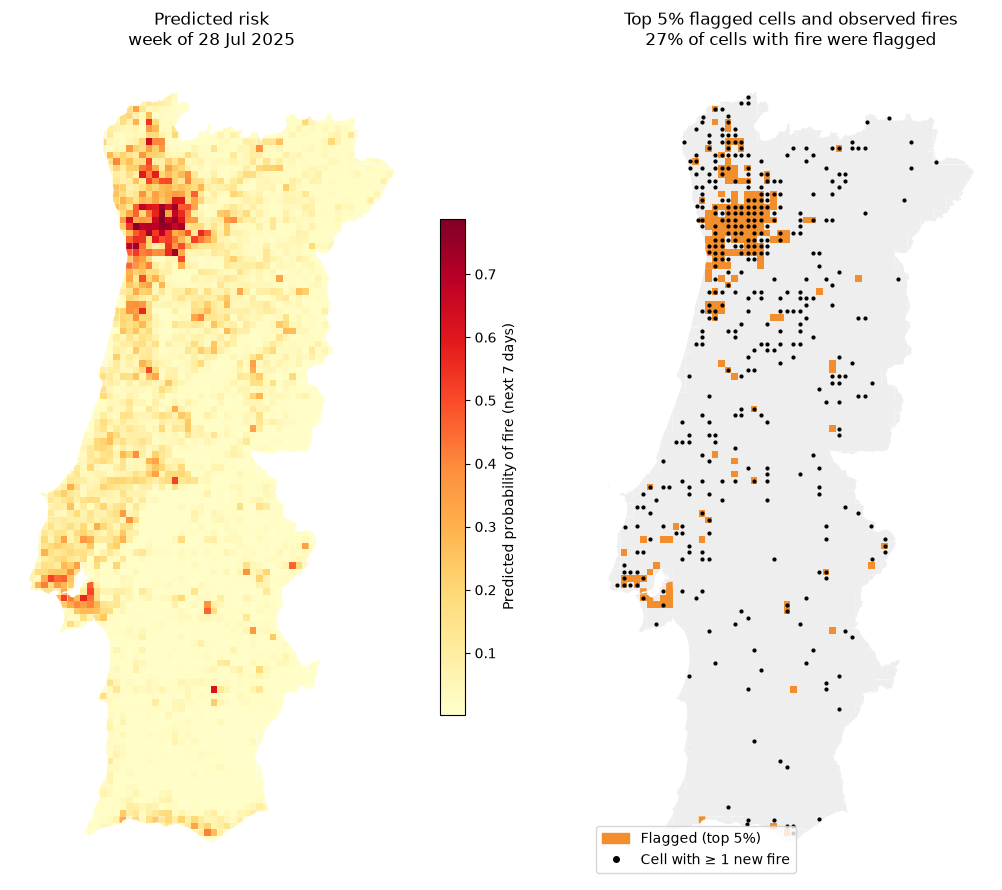

In [9]:
weekly_fires_2025 = test_scores[test_scores["year"] == 2025].groupby("reference_date")["y"].sum()
map_week = weekly_fires_2025.idxmax()

week = grid[["cell_id", "geometry"]].merge(
    test_scores.loc[test_scores["reference_date"] == map_week, ["cell_id", PRIMARY_CAL, "y"]],
    on="cell_id", how="inner",
)
week["geometry"] = week.geometry.intersection(portugal)        # clip cells to Portugal
week["flagged"] = week[PRIMARY_CAL].rank(ascending=False, method="first") <= 191
captured = week.loc[week["y"] == 1, "flagged"].mean()

fig, axes = plt.subplots(1, 2, figsize=(11, 9))

week.plot(column=PRIMARY_CAL, cmap="YlOrRd", ax=axes[0], legend=True,
          legend_kwds={"label": "Predicted probability of fire (next 7 days)", "shrink": 0.6})
axes[0].set_title(f"Predicted risk\nweek of {map_week:%d %b %Y}")

week.plot(ax=axes[1], color="#eeeeee")
week[week["flagged"]].plot(ax=axes[1], color="#f28e2b")
week[week["y"] == 1].geometry.centroid.plot(ax=axes[1], color="black", markersize=4)
axes[1].set_title(f"Top 5% flagged cells and observed fires\n"
                  f"{captured:.0%} of cells with fire were flagged")
axes[1].legend(handles=[
    Patch(color="#f28e2b", label="Flagged (top 5%)"),
    Line2D([], [], marker="o", color="black", linestyle="", markersize=4,
           label="Cell with ≥ 1 new fire"),
], loc="lower left")

for ax in axes:
    ax.set_axis_off()

plt.tight_layout()
fig.savefig(FIG_DIR / "risk_map_week.png", dpi=150, bbox_inches="tight")
plt.show()

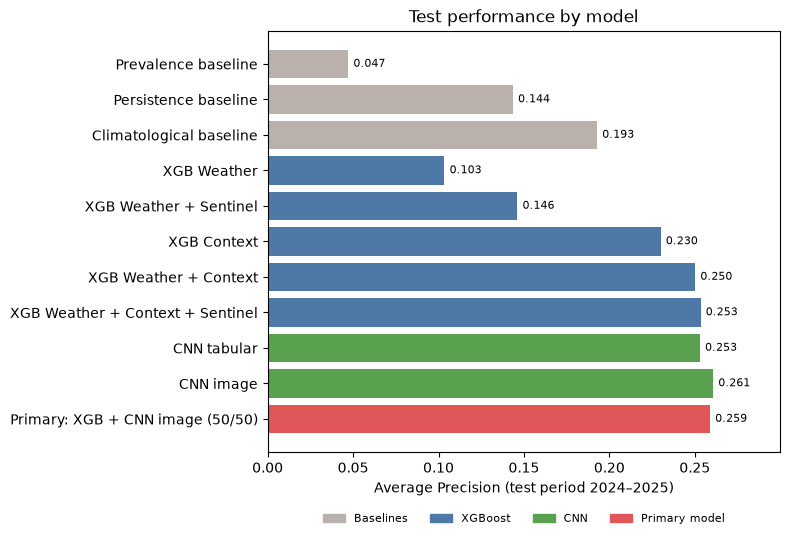

In [13]:
plot_models = {
    "Prevalence baseline": "baseline",
    "Persistence baseline": "baseline",
    "Climatological baseline": "baseline",
    "XGB Weather": "tabular",
    "XGB Weather + Sentinel": "tabular",
    "XGB Context": "tabular",
    "XGB Weather + Context": "tabular",
    "XGB Weather + Context + Sentinel": "tabular",
    "CNN tabular": "cnn",
    "CNN image": "cnn",
    PRIMARY: "primary",
}

ap_test = test_results.set_index("model").loc[list(plot_models), "AP 2024–2025"]

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(range(len(ap_test)), ap_test.values,
        color=[COLORS[plot_models[m]] for m in ap_test.index])
ax.set_yticks(range(len(ap_test)),
              labels=[m.replace("PRIMARY: ", "Primary: ") for m in ap_test.index])
ax.invert_yaxis()

for i, value in enumerate(ap_test.values):
    ax.text(value + 0.003, i, f"{value:.3f}", va="center", fontsize=8)

ax.set_xlim(0, ap_test.max() * 1.15)
ax.set_xlabel("Average Precision (test period 2024–2025)")
ax.set_title("Test performance by model")
ax.legend(
    handles=[
        Patch(color=COLORS["baseline"], label="Baselines"),
        Patch(color=COLORS["tabular"], label="XGBoost"),
        Patch(color=COLORS["cnn"], label="CNN"),
        Patch(color=COLORS["primary"], label="Primary model"),
    ],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=4,
    frameon=False,
    fontsize=8,
)

plt.tight_layout()
fig.savefig(FIG_DIR / "test_ap_by_model.png", dpi=150, bbox_inches="tight")
plt.show()

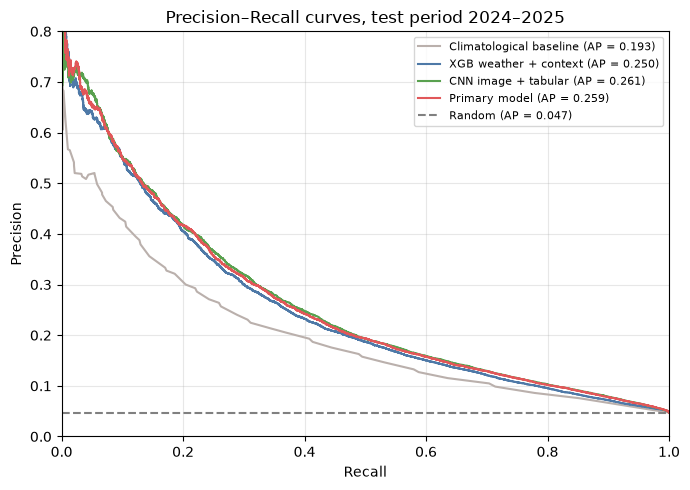

In [11]:
pr_models = {
    "Climatological baseline": ("Climatological baseline", COLORS["baseline"]),
    "XGB Weather + Context": ("XGB weather + context", COLORS["tabular"]),
    "CNN image": ("CNN image + tabular", COLORS["cnn"]),
    PRIMARY: ("Primary model", COLORS["primary"]),
}

fig, ax = plt.subplots(figsize=(7, 5))
for column, (label, color) in pr_models.items():
    precision, recall, _ = precision_recall_curve(test_scores["y"], test_scores[column])
    ap = average_precision_score(test_scores["y"], test_scores[column])
    ax.plot(recall, precision, color=color, label=f"{label} (AP = {ap:.3f})")

prevalence = test_scores["y"].mean()
ax.axhline(prevalence, linestyle="--", color="grey", label=f"Random (AP = {prevalence:.3f})")

ax.set_xlim(0, 1)
ax.set_ylim(0, 0.8)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision–Recall curves, test period 2024–2025")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(FIG_DIR / "pr_curves_test.png", dpi=150, bbox_inches="tight")
plt.show()  

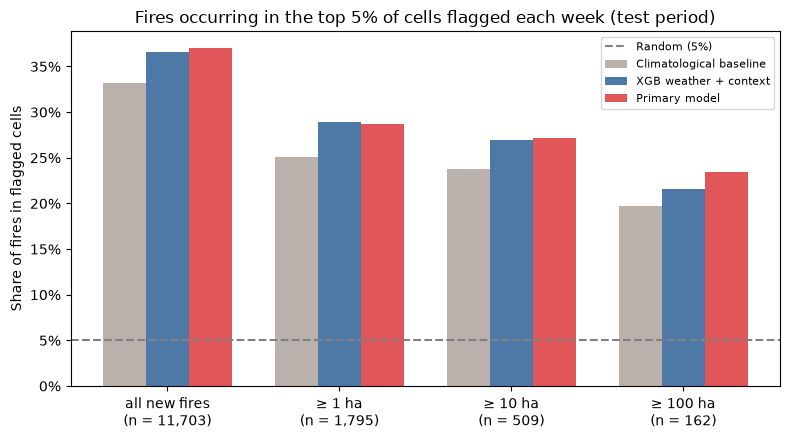

In [12]:
lf = large_fire_results.set_index("fire size")
bar_models = {
    "Climatological baseline": ("Climatological baseline", COLORS["baseline"]),
    "XGB Weather + Context": ("XGB weather + context", COLORS["tabular"]),
    PRIMARY: ("Primary model", COLORS["primary"]),
}

x = np.arange(len(lf))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 4.5))
for i, (column, (label, color)) in enumerate(bar_models.items()):
    ax.bar(x + (i - 1) * width, lf[column].values, width, color=color, label=label)

ax.axhline(0.05, linestyle="--", color="grey", label="Random (5%)")
ax.set_xticks(x, labels=[f"{size}\n(n = {n:,})" for size, n in zip(lf.index, lf["n_fires"])])
ax.set_ylabel("Share of fires in flagged cells")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_title("Fires occurring in the top 5% of cells flagged each week (test period)")
ax.legend(fontsize=8)

plt.tight_layout()
fig.savefig(FIG_DIR / "large_fire_capture.png", dpi=150, bbox_inches="tight")
plt.show()